# Exploratory Data Analysis — Children Speech Recognition

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from pathlib import Path
from collections import Counter

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Load Transcripts

In [2]:
DATA_DIR = Path('../data/raw')
TRANSCRIPT_PATH = DATA_DIR / 'train_word_transcripts.jsonl'
AUDIO_PARTS = ['audio_part_0', 'audio_part_1', 'audio_part_2']

records = []
with open(TRANSCRIPT_PATH, 'r') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

df['word_count'] = df['orthographic_text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['orthographic_text'].apply(lambda x: len(str(x)))
df['speaking_rate'] = df['word_count'] / df['audio_duration_sec'].replace(0, np.nan)

print(f'Total samples:     {len(df):,}')
print(f'Unique children:   {df["child_id"].nunique():,}')
print(f'Unique sessions:   {df["session_id"].nunique():,}')
print(f'Age buckets:       {sorted(df["age_bucket"].unique())}')
df.head()

Total samples:     95,572
Unique children:   2,175
Unique sessions:   5,197
Age buckets:       ['3-4', '5-7', '8-11']


,utterance_id,child_id,session_id,audio_path,audio_duration_sec,age_bucket,md5_hash,filesize_bytes,orthographic_text,word_count,char_count,speaking_rate
0,U_00003c3ae1c35c6f,C_c74bfde2cca8d5da,S_7d821c3e4d3bc616,audio/U_00003c3ae1c35c6f.flac,1.920,8-11,9214be45ba2928dd57384f3c7ee54236,30672,hm,1,2,0.520833
1,U_00003db24218ffe4,C_c74bfde2cca8d5da,S_e6103ab3a4538d71,audio/U_00003db24218ffe4.flac,12.737,8-11,fe761bb3d034530ef05163c7ad98ec3e,180942,yeah its pouring the water on the screen but t...,27,133,2.119808
2,U_0001a0d0a3b4d816,C_4d0e1c16566d65a2,S_179057c3c3ccdecf,audio/U_0001a0d0a3b4d816.flac,11.556,8-11,b05073e65a98368fccbe777b5ab35e02,208352,it got water and sunlight but the plant did di...,23,123,1.990308
3,U_00021d201a31d313,C_3b51c8b1d2c076d8,S_90720887e4430996,audio/U_00021d201a31d313.flac,1.125,8-11,9ed95318724ae6a2d1ce95d6aa743f6b,27099,there is wires,3,14,2.666667
4,U_0003537f2bc1eb0b,C_b50216b3c70ca0a2,S_5b0bb48fadd7f802,audio/U_0003537f2bc1eb0b.flac,1.125,8-11,f3142751c6a52e2c24a85a4544fe8a0f,18476,good,1,4,0.888889


## 2. Missing Values & Data Quality

In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicate utterance IDs ===')
print(df['utterance_id'].duplicated().sum())

print('\n=== Empty transcripts ===')
empty = df[df['orthographic_text'].apply(lambda x: str(x).strip() == '')]
print(f'{len(empty)} empty transcripts')

print('\n=== Very short clips (< 0.5s) ===')
short = df[df['audio_duration_sec'] < 0.5]
print(f'{len(short)} clips under 0.5 seconds')

print('\n=== Very long clips (> 30s) ===')
long = df[df['audio_duration_sec'] > 30]
print(f'{len(long)} clips over 30 seconds')

=== Missing Values ===
utterance_id          0
child_id              0
session_id            0
audio_path            0
audio_duration_sec    0
age_bucket            0
md5_hash              0
filesize_bytes        0
orthographic_text     0
word_count            0
char_count            0
speaking_rate         0
dtype: int64

=== Duplicate utterance IDs ===
0

=== Empty transcripts ===
0 empty transcripts

=== Very short clips (< 0.5s) ===
1725 clips under 0.5 seconds

=== Very long clips (> 30s) ===
2192 clips over 30 seconds


## 3. Age Bucket Distribution

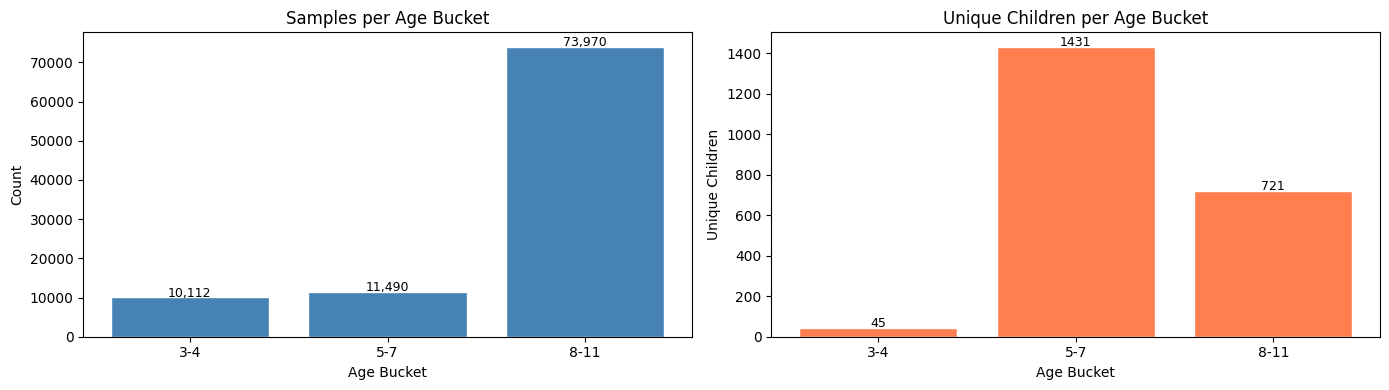


Average utterances per child per age bucket:
age_bucket
3-4     224.7
5-7       8.0
8-11    102.6
dtype: float64


In [4]:
age_counts = df['age_bucket'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Samples per Age Bucket')
axes[0].set_xlabel('Age Bucket')
axes[0].set_ylabel('Count')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

unique_children = df.groupby('age_bucket')['child_id'].nunique().sort_index()
axes[1].bar(unique_children.index, unique_children.values, color='coral', edgecolor='white')
axes[1].set_title('Unique Children per Age Bucket')
axes[1].set_xlabel('Age Bucket')
axes[1].set_ylabel('Unique Children')
for i, v in enumerate(unique_children.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nAverage utterances per child per age bucket:')
print((age_counts / unique_children).round(1))

## 4. Audio Duration Analysis

=== Overall Duration Stats (seconds) ===
count    95572.00
mean         6.98
std          9.28
min          0.08
25%          1.78
50%          4.09
75%          9.05
max       1348.69
Name: audio_duration_sec, dtype: float64

Total audio: 185.37 hours


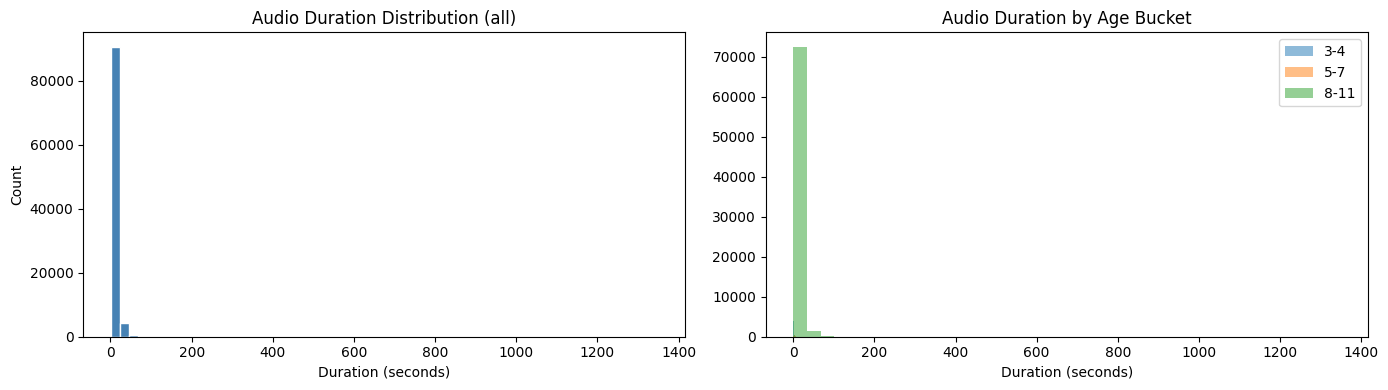


=== Duration stats per age bucket ===
              count  mean    std   min   25%   50%    75%      max
age_bucket                                                        
3-4         10112.0  1.67   1.36  0.15  0.91  1.26   1.95    21.38
5-7         11490.0  3.37   1.96  0.40  1.72  2.79   4.71    10.00
8-11        73970.0  8.27  10.14  0.08  2.30  5.37  11.14  1348.69


In [5]:
print('=== Overall Duration Stats (seconds) ===')
print(df['audio_duration_sec'].describe().round(2))
total_hours = df['audio_duration_sec'].sum() / 3600
print(f'\nTotal audio: {total_hours:.2f} hours')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['audio_duration_sec'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Audio Duration Distribution (all)')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')

age_groups = df.groupby('age_bucket')['audio_duration_sec']
for name, group in age_groups:
    axes[1].hist(group, bins=40, alpha=0.5, label=name)
axes[1].set_title('Audio Duration by Age Bucket')
axes[1].set_xlabel('Duration (seconds)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n=== Duration stats per age bucket ===')
print(df.groupby('age_bucket')['audio_duration_sec'].describe().round(2))

## 5. Transcript & Speaking Rate Analysis

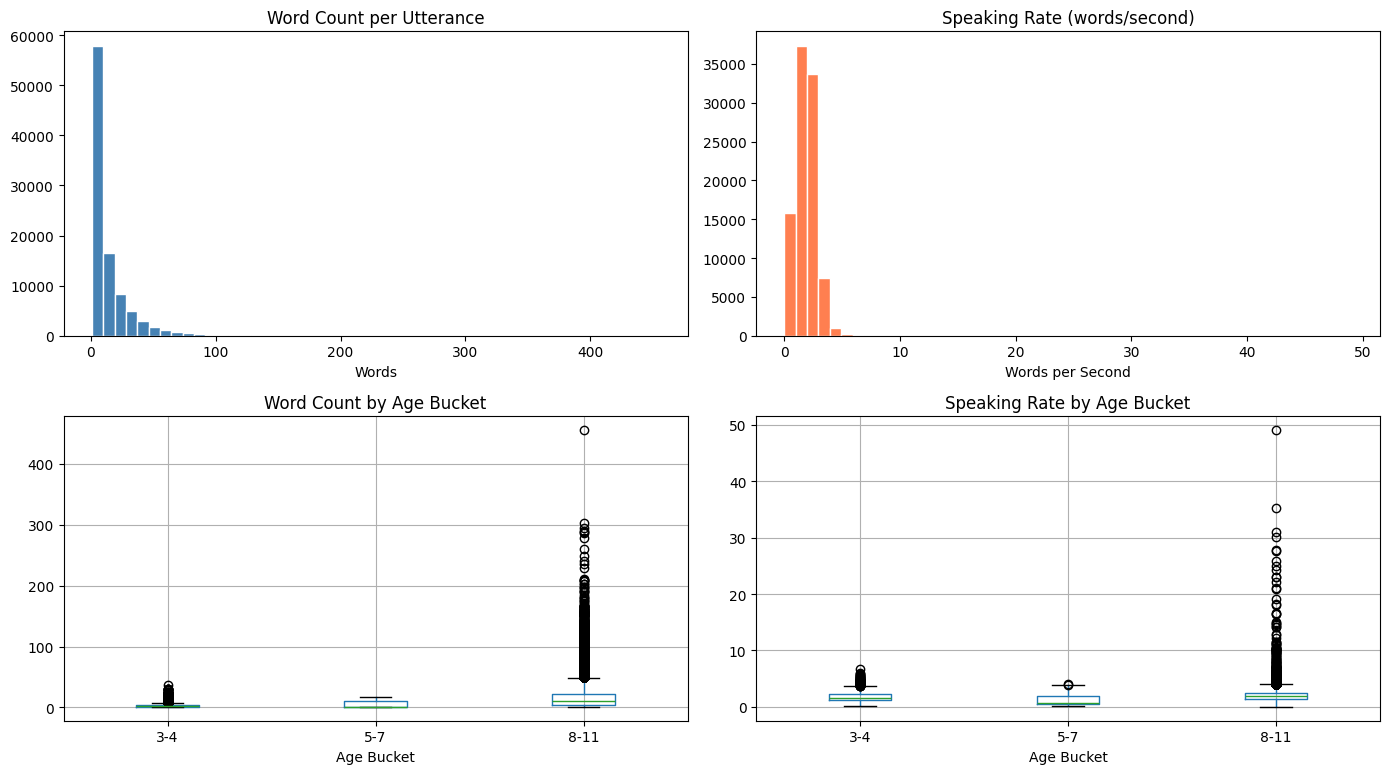

=== Speaking Rate stats per age bucket (words/sec) ===
              count   mean    std    min    25%    50%    75%     max
age_bucket                                                           
3-4         10112.0  1.746  0.778  0.199  1.159  1.581  2.201   6.757
5-7         11490.0  1.131  0.815  0.100  0.474  0.746  1.846   4.082
8-11        73970.0  1.989  0.913  0.001  1.437  1.954  2.463  49.037


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Word Count per Utterance')
axes[0, 0].set_xlabel('Words')

axes[0, 1].hist(df['speaking_rate'].dropna(), bins=50, color='coral', edgecolor='white')
axes[0, 1].set_title('Speaking Rate (words/second)')
axes[0, 1].set_xlabel('Words per Second')

df.boxplot(column='word_count', by='age_bucket', ax=axes[1, 0])
axes[1, 0].set_title('Word Count by Age Bucket')
axes[1, 0].set_xlabel('Age Bucket')
plt.sca(axes[1, 0])
plt.title('Word Count by Age Bucket')

df.boxplot(column='speaking_rate', by='age_bucket', ax=axes[1, 1])
axes[1, 1].set_title('Speaking Rate by Age Bucket')
axes[1, 1].set_xlabel('Age Bucket')
plt.sca(axes[1, 1])
plt.title('Speaking Rate by Age Bucket')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('=== Speaking Rate stats per age bucket (words/sec) ===')
print(df.groupby('age_bucket')['speaking_rate'].describe().round(3))

## 6. Vocabulary Analysis

Total tokens:          1,289,614
Unique vocabulary:     10,734
Singleton words:       3,871


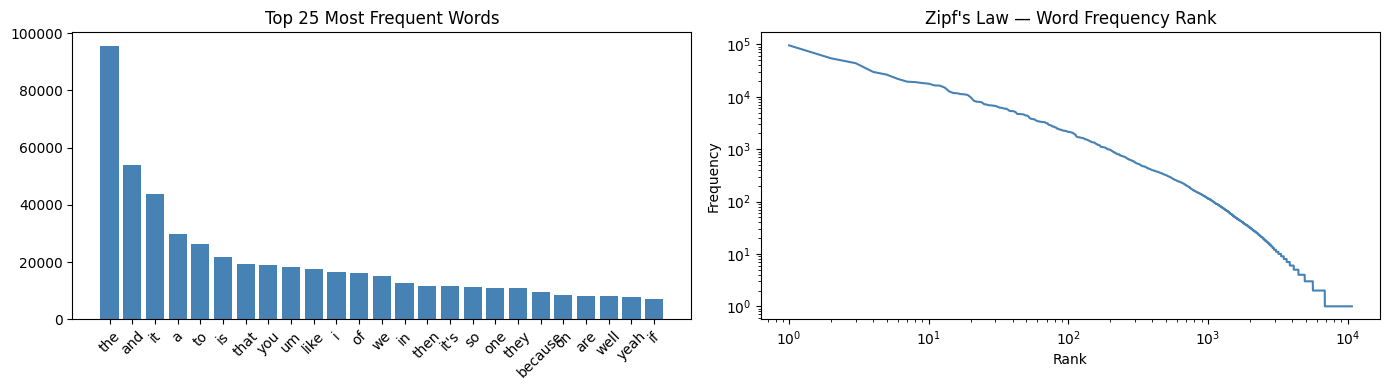


=== Vocabulary per Age Bucket ===
3-4: 1,904 unique words
5-7: 760 unique words
8-11: 10,216 unique words


In [7]:
all_words = ' '.join(df['orthographic_text'].dropna().tolist()).lower().split()
word_freq = Counter(all_words)
vocab = set(all_words)

print(f'Total tokens:          {len(all_words):,}')
print(f'Unique vocabulary:     {len(vocab):,}')
print(f'Singleton words:       {sum(1 for c in word_freq.values() if c == 1):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_words = word_freq.most_common(25)
words, counts = zip(*top_words)
axes[0].bar(words, counts, color='steelblue')
axes[0].set_title('Top 25 Most Frequent Words')
axes[0].tick_params(axis='x', rotation=45)

freq_values = sorted(word_freq.values(), reverse=True)
axes[1].loglog(range(1, len(freq_values)+1), freq_values, color='steelblue')
axes[1].set_title("Zipf's Law — Word Frequency Rank")
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('\n=== Vocabulary per Age Bucket ===')
for age, group in df.groupby('age_bucket'):
    words_age = ' '.join(group['orthographic_text'].dropna()).lower().split()
    print(f'{age}: {len(set(words_age)):,} unique words')

## 7. Correlation Analysis

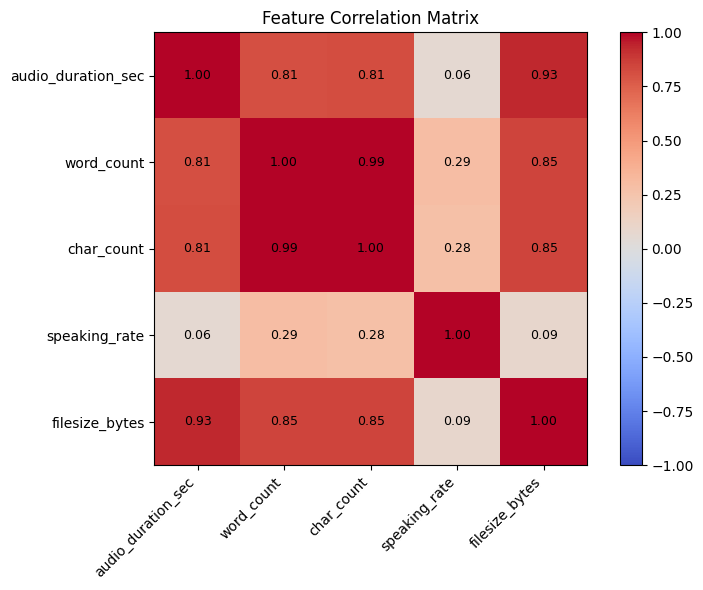

In [8]:
corr_cols = ['audio_duration_sec', 'word_count', 'char_count', 'speaking_rate', 'filesize_bytes']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Audio Waveform & Spectrogram Comparison Across Age Groups

c:\Users\adnan\OneDrive\Desktop\Projects\Children_Speech_Recognition\speech_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


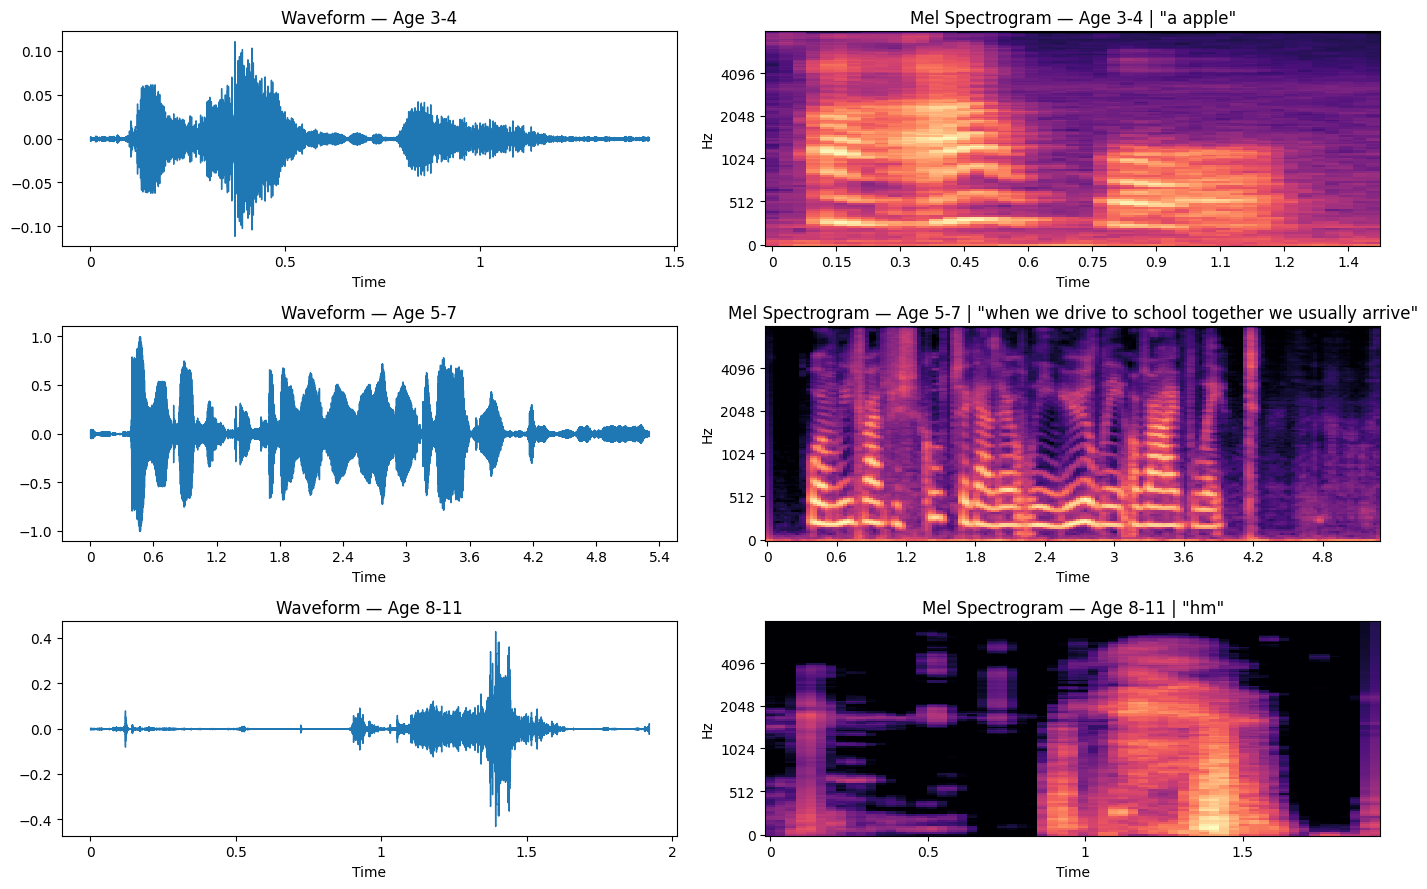

In [9]:
def find_audio(row):
    for part in AUDIO_PARTS:
        candidate = DATA_DIR / part / row['audio_path']
        if candidate.exists():
            return candidate
    return None

age_buckets = sorted(df['age_bucket'].unique())
samples = {age: df[df['age_bucket'] == age].iloc[0] for age in age_buckets}

n = len(age_buckets)
fig, axes = plt.subplots(n, 2, figsize=(14, 3 * n))

for i, (age, row) in enumerate(samples.items()):
    audio_file = find_audio(row)
    if audio_file is None:
        continue
    y, sr = librosa.load(audio_file, sr=16000)

    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f'Waveform — Age {age}')

    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)
    librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'Mel Spectrogram — Age {age} | "{row["orthographic_text"][:50]}"')

plt.tight_layout()
plt.show()

## 9. Pitch (F0) Analysis by Age Group

In [10]:
print('Estimating pitch for one sample per age bucket...')

pitch_stats = {}
for age, row in samples.items():
    audio_file = find_audio(row)
    if audio_file is None:
        continue
    y, sr = librosa.load(audio_file, sr=16000)
    f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
    voiced_f0 = f0[voiced_flag]
    if len(voiced_f0) > 0:
        pitch_stats[age] = {'mean': np.mean(voiced_f0), 'median': np.median(voiced_f0)}
        print(f'Age {age}: mean F0 = {np.mean(voiced_f0):.1f} Hz, median = {np.median(voiced_f0):.1f} Hz')

print('\nNote: Higher F0 = higher pitched voice. Children generally have higher F0 than adults.')

Estimating pitch for one sample per age bucket...
Age 3-4: mean F0 = 282.9 Hz, median = 292.8 Hz
Age 5-7: mean F0 = 214.7 Hz, median = 205.3 Hz

Note: Higher F0 = higher pitched voice. Children generally have higher F0 than adults.


## 10. Noise Files Analysis

Total noise files: 1940


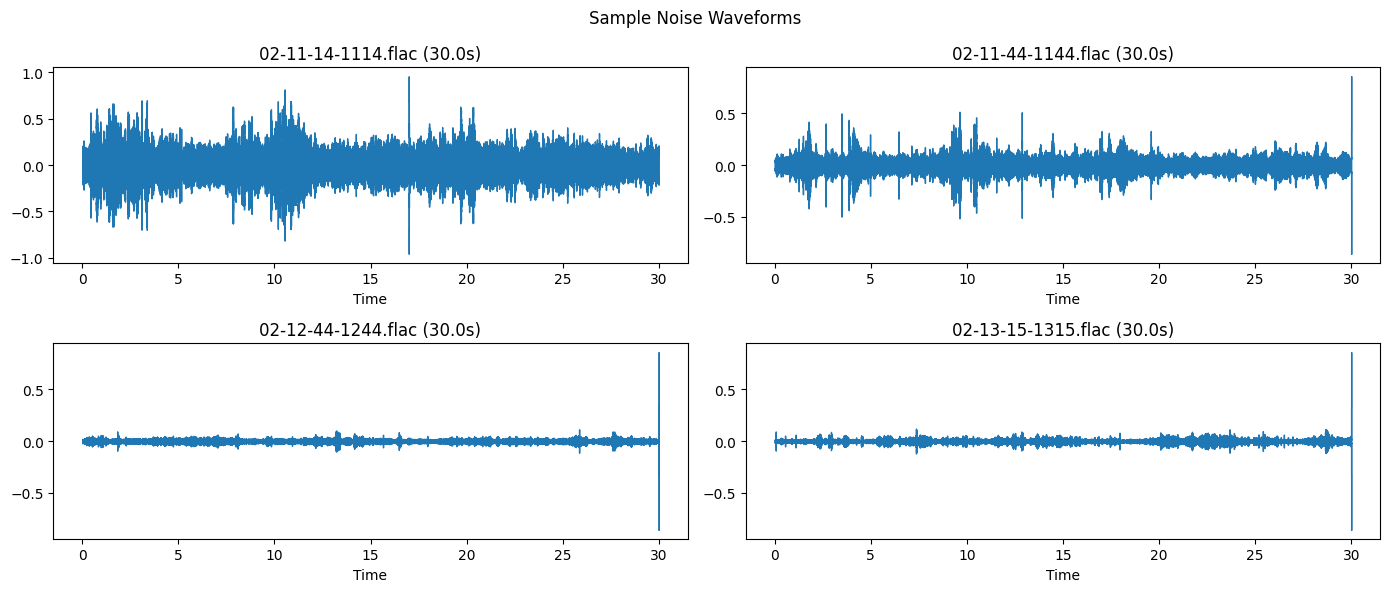

In [11]:
noise_files = []
for part in ['noise_part_0', 'noise_part_1']:
    noise_dir = DATA_DIR / part
    if noise_dir.exists():
        noise_files += list(noise_dir.rglob('*.flac'))

print(f'Total noise files: {len(noise_files)}')

if noise_files:
    fig, axes = plt.subplots(2, 2, figsize=(14, 6))
    for i, nf in enumerate(noise_files[:4]):
        y_n, sr_n = librosa.load(nf, sr=16000)
        ax = axes[i // 2, i % 2]
        librosa.display.waveshow(y_n, sr=sr_n, ax=ax)
        ax.set_title(f'{nf.name} ({len(y_n)/sr_n:.1f}s)')
    plt.suptitle('Sample Noise Waveforms')
    plt.tight_layout()
    plt.show()

## 11. Summary & Key Findings

In [12]:
print('=' * 50)
print('DATASET SUMMARY')
print('=' * 50)
print(f'Total utterances:      {len(df):,}')
print(f'Unique children:       {df["child_id"].nunique():,}')
print(f'Unique sessions:       {df["session_id"].nunique():,}')
print(f'Total audio (hours):   {df["audio_duration_sec"].sum()/3600:.2f}')
print(f'Avg duration (sec):    {df["audio_duration_sec"].mean():.2f}')
print(f'Avg words/utterance:   {df["word_count"].mean():.1f}')
print(f'Avg speaking rate:     {df["speaking_rate"].mean():.2f} words/sec')
print(f'Vocabulary size:       {len(vocab):,}')
print(f'Age buckets:           {sorted(df["age_bucket"].unique())}')
print(f'Noise files:           {len(noise_files)}')

DATASET SUMMARY
Total utterances:      95,572
Unique children:       2,175
Unique sessions:       5,197
Total audio (hours):   185.37
Avg duration (sec):    6.98
Avg words/utterance:   13.5
Avg speaking rate:     1.86 words/sec
Vocabulary size:       10,734
Age buckets:           ['3-4', '5-7', '8-11']
Noise files:           1940
